In [ ]:


import os
import pandas as pd
data_folder = '../data/'
path = os.path.join(data_folder)

df = pd.DataFrame()
df2 = pd.DataFrame()
for file in os.listdir(path):
    if 'price_history' in file:
        df2 = pd.read_csv(data_folder + file)
        df = pd.concat([df, df2])
        

meta_path = '../data/all_products_meta.csv'
meta_df = pd.read_csv(meta_path)

df = df.merge(meta_df, on = 'asin')

KEEPA_EPOCH = pd.Timestamp('2011-01-01')
df['listedSince'] = pd.to_datetime(KEEPA_EPOCH + pd.to_timedelta(df['listedSince'], 'min'))
df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['listedSince']).dt.days
df = df[df['days_since_launch'] > 0]

df['median'] = df.groupby('asin')['NEW'].transform('median')
df = df[df['NEW'] < 3 * df['median']]
df = df[df['NEW'].notna()]

df = df.set_index('datetime', drop = True)
backup_df = df
df = df.groupby('asin').resample('W')['NEW'].min().reset_index()
df['NEW'] = df.groupby('asin')['NEW'].ffill()

df = df.merge(meta_df[['asin', 'brand', 'model', 'listedSince']], on='asin', how='left')
df['listedSince'] = pd.to_datetime(KEEPA_EPOCH + pd.to_timedelta(df['listedSince'], 'min'))
df['days_since_launch'] = (df['datetime'] - df['listedSince']).dt.days

import plotly.express as px
iphone_13_df = df[df['model'] == 'iPhone 13']
chart = px.line(iphone_13_df, x = 'days_since_launch', y = 'NEW')
chart.show()

In [ ]:
all_iphones_df = df[df['brand'] == 'Apple']
print(all_iphones_df.head())

all_iphones_line_chart = px.line(
    all_iphones_df,
    x = 'days_since_launch',
    y = 'NEW',
    color = 'model'
    )

all_iphones_line_chart.show()

In [ ]:
all_iphones_df['month'] = all_iphones_df['datetime'].dt.to_period('M')

summary = all_iphones_df.groupby(['asin', 'month'])['NEW'].agg(
    min_price='min',
    max_price='max',
    first_price='first',
    last_price='last'
).reset_index()

# summary.head()

all_iphones_df['first_price'] = all_iphones_df.groupby('model')['NEW'].transform('first')
all_iphones_df['last_price'] = all_iphones_df.groupby('model')['NEW'].transform('last')
all_iphones_df['max_price'] = all_iphones_df.groupby('model')['NEW'].transform('max')
all_iphones_df['min_price'] = all_iphones_df.groupby('model')['NEW'].transform('min')
all_iphones_df['weekly_drop'] = all_iphones_df.groupby('model')['NEW'].diff(1).abs()


summary = all_iphones_df.groupby('model')[['first_price', 'last_price']].first()
summary['total_drop_pct'] = round((summary['first_price'] - summary['last_price']) / summary['first_price'] * 100, 1)
summary = summary.sort_values('total_drop_pct', ascending = False)
summary['max_weekly_drop'] = all_iphones_df.groupby('model')['weekly_drop'].max()
summary.head(7)


In [ ]:
#W2 D3 
'''Add a new column `mean_price` to `all_iphones_df` — the mean NEW price for that model,
aligned to every row (same value repeated for all rows of the same model).
Print head() showing model, NEW, and mean_price columns only.'''
all_iphones_df['mean_price'] = all_iphones_df.groupby('model')['NEW'].transform('mean')


'''Build a summary DataFrame with one row per model, columns:
- `mean_price` — mean weekly NEW price
- `std_price` — standard deviation of weekly NEW prices
- `weeks_of_data` — number of weekly price points'''
summary_df = all_iphones_df.groupby('model').agg(mean_price=('NEW', 'mean'), std_price = ('NEW', 'std'), weeks_of_data = ('NEW', 'count')).reset_index()


'''From the full resampled `df` (all ASINs), identify:
- The 2 Samsung ASINs with the most weekly price points
- The 2 Google ASINs with the most weekly price points
'''
top_asins = df.groupby(['brand', 'model', 'asin']).agg(weekly_price_points = ('NEW', 'count')).reset_index()
top_asins = top_asins.sort_values('weekly_price_points', ascending = False)
top_asins.head(12)



'''Filter `df` to: all Apple iPhones + the 4 chosen ASINs.
Compute the decay summary table (first_price, last_price, total_drop_pct) grouped by model.
Print sorted by total_drop_pct descending.'''

filtered_df = df[(df['brand'] == 'Apple') | (df['asin'].isin(['B08L34JQ9C', 'B08VLMQ3KS', 'B08MV7HWFK', 'B09SYSMCX6']))]
filtered_df = df.groupby('model').agg(first_price = ('NEW', 'first'), last_price = ('NEW', 'last')).reset_index()
filtered_df['total_drop_pct'] = round((filtered_df['first_price'] - filtered_df['last_price']) / filtered_df['first_price'] * 100, 1)
filtered_df = filtered_df.sort_values('total_drop_pct', ascending = False)
filtered_df.head()


'''Plot decay curves for all selected models on one px.line chart.
x = days_since_launch, y = NEW, color = brand.
Title: "Price Decay by Brand".
One observation: which brand decays fastest?'''


import plotly.express as px
decay_chart = px.line(x = df['days_since_launch'], y = df['NEW'], color = df['brand'])
# decay_chart.show()


'''Add column `price_pct_of_launch` to the filtered DataFrame:
price as a percentage of that model's first recorded price.
Formula: `NEW / first_price * 100`
You already know how to get first_price per model. Print min, max, and head().
'''

df['first_price'] = df.groupby('model')['NEW'].transform('first')
df['price_pct_of_launch'] = round(df['NEW'] / df['first_price'] * 100, 1)
df.head()

decay_chart_price_pct = px.line(x = df['days_since_launch'], y = df['price_pct_of_launch'], color = df['brand'], title = 'Price decay - pct of launch price by brand')
decay_chart_price_pct.show()



In [60]:
#W2 D4
'''From `df`, create `brand_decay_df`:
- Group by `brand` and `days_since_launch`
- Compute mean `price_pct_of_launch` per group
- Reset index
- Result: one row per brand per days_since_launch value

Print shape and head(). How many unique days_since_launch values are there per brand?'''


brand_decay_df = df.groupby(['brand', 'days_since_launch'])['price_pct_of_launch'].mean().reset_index().sort_values(['brand', 'days_since_launch'])
brand_decay_df.head()
#This is very unintuitive STILL - I had to assist myself A BIT with LLM after some tries...
print(brand_decay_df.value_counts(['brand']))


#T2 
'''Plot `brand_decay_df` as a line chart using px.line:
- x = days_since_launch, y = price_pct_of_launch (mean), color = brand
- Title: "Average Price Decay by Brand — % of Launch Price"
- Add a horizontal dashed line at y=50 (hint: use `fig.add_hline(y=50, line_dash="dash")`)
- Which brand crosses 50% first?
'''
pd.set_option('display.max_rows', 200)

chart = px.line(brand_decay_df,
    x = 'days_since_launch',
    y = 'price_pct_of_launch',
    color = 'brand',
    title = 'Average Price Decay by Brand — % of Launch Price'
    )
chart = chart.add_hline(y = 50, line_dash = 'dash')
chart.show()
    
    
'''
Adrian's note:

Data is really weird here and we have lots of 100.00 and below 100. values put randomly in certain date areas.
I reckon it's because some data is bugged. We could handle this by replacing 100 and above with NaN and then using ffill/bfill or averaging the two prices to get the right values.
That's my idea for now.

And also, while I don't see any duplicate in terms of days and values, the line chart contains weird shadows, as if these were area charts, when they're clearly NOT.

	brand	days_since_launch	price_pct_of_launch
0	Apple	6	100.00
1	Apple	13	98.90
2	Apple	17	100.00
3	Apple	20	95.90
4	Apple	24	96.10
5	Apple	27	92.70
6	Apple	31	98.00
7	Apple	34	89.00
8	Apple	38	96.90
9	Apple	41	87.50
10	Apple	45	91.30
11	Apple	48	84.50
12	Apple	52	89.50
13	Apple	55	82.80
14	Apple	59	88.10
15	Apple	62	82.20
16	Apple	65	100.00
17	Apple	66	86.30
18	Apple	69	82.10
19	Apple	72	100.00
20	Apple	73	86.90
21	Apple	74	100.00
22	Apple	76	83.00
23	Apple	79	100.00
24	Apple	80	86.00
25	Apple	81	100.00
26	Apple	83	82.65
27	Apple	86	99.85
28	Apple	87	84.90
29	Apple	88	106.00
30	Apple	90	82.55
31	Apple	93	99.85
32	Apple	94	85.30
33	Apple	95	106.00
34	Apple	97	81.90
35	Apple	100	115.10
36	Apple	101	86.40
37	Apple	102	100.10
38	Apple	104	80.20
39	Apple	107	115.45
40	Apple	108	84.40
41	Apple	109	100.10
42	Apple	111	81.70
43	Apple	114	99.70
44	Apple	115	83.70
45	Apple	116	94.10
46	Apple	118	78.75
47	Apple	121	102.75
48	Apple	122	83.20
49	Apple	123	93.90
'''




brand  
Apple      857
Google     657
Samsung    526
Name: count, dtype: int64


"\nAdrian's note:\n\nData is really weird here and we have lots of 100.00 and below 100. values put randomly in certain date areas.\nI reckon it's because some data is bugged. We could handle this by replacing 100 and above with NaN and then using ffill/bfill or averaging the two prices to get the right values.\nThat's my idea for now.\n\nAnd also, while I don't see any duplicate in terms of days and values, the line chart contains weird shadows, as if these were area charts, when they're clearly NOT.\n\n\tbrand\tdays_since_launch\tprice_pct_of_launch\n0\tApple\t6\t100.00\n1\tApple\t13\t98.90\n2\tApple\t17\t100.00\n3\tApple\t20\t95.90\n4\tApple\t24\t96.10\n5\tApple\t27\t92.70\n6\tApple\t31\t98.00\n7\tApple\t34\t89.00\n8\tApple\t38\t96.90\n9\tApple\t41\t87.50\n10\tApple\t45\t91.30\n11\tApple\t48\t84.50\n12\tApple\t52\t89.50\n13\tApple\t55\t82.80\n14\tApple\t59\t88.10\n15\tApple\t62\t82.20\n16\tApple\t65\t100.00\n17\tApple\t66\t86.30\n18\tApple\t69\t82.10\n19\tApple\t72\t100.00\n20\tAppl

Text(0.5, 1.0, 'Price retention distribution by brand')

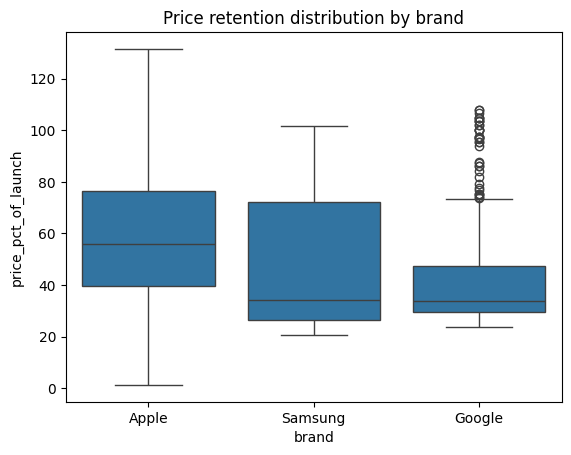

In [59]:
#W2 D4 Part 2 - T3, T4, T5


'''Work in 03_analysis.ipynb. Use `df` filtered to Apple, Samsung (B08L34JQ9C, B08VLMQ3KS),
Google (B08MV7HWFK, B09SYSMCX6) only — call this `selected_df`.'''
import seaborn as sns

selected_df = df[(df['brand'] == 'Apple') | df['asin'].isin(['B08L34JQ9C', 'B08VLMQ3KS','B08MV7HWFK', 'B09SYSMCX6'])].copy()

'''Using `selected_df`, plot a Seaborn box plot:
- x = brand, y = price_pct_of_launch
- Title: "Price Retention Distribution by Brand"
- What does the spread of each box tell you?'''

# selected_df.head()
# box_plot = sns.boxplot(
#     selected_df,
#     x = 'brand',
#     y = 'price_pct_of_launch'
#     )
# box_plot.set_title('Price retention distribution by brand')

'''Sort the x-axis by median `price_pct_of_launch` descending (highest retention on left).
- Compute per-brand median, sort, pass order to seaborn's `order` parameter
- Print the sorted brand order before plotting'''

selected_df_order = selected_df.groupby('brand')['price_pct_of_launch'].median().reset_index()
selected_df_order = selected_df_order.sort_values('price_pct_of_launch', ascending = False)
selected_df_order.head()

selected_df.head()
box_plot = sns.boxplot(
    selected_df,
    x = 'brand',
    y = 'price_pct_of_launch',
    order = selected_df_order['brand']
    )
box_plot.set_title('Price retention distribution by brand')


#W2 D4 - Markdown cell with analysis

1. We need to fix the values first and handle the spikes properly. However, it seems like Apple crosses the 50% boundary as the last of the other two brands. Why is that? Maybe there's higher demand for iPhones than other brands and perhaps they do not age so fast (depends, but maybe due to brand support, updates and quality of tech, so it still stays fresh). I know that iPhones are/were famous for their camera quality.
2. If you mean the line curve - it's mostly a downtrend with occassional spikes, but we need to handle the shadows in display and the outliers.
3. I've already kinda named it, we have some shadows and outliers that we need to handle with care and do not rush it, so that we don't make mistakes. Keepa API wasn't a perfect data source, and I guess it wasn't designed for price history analysis for few years in the past.